## EDA (Exploratory Data Analysis)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use("ggplot") #(for styling)

In [3]:
df = pd.read_csv("../data/cleaned_data.csv")
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales,Year,Month,Day
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4,2009,12,1
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0,2009,12,1
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8,2009,12,1
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0,2009,12,1


### dataset overview

In [5]:
print("Dataset Shape:", df.shape)
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df.info()

Dataset Shape: (779425, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 779425 entries, 0 to 779424
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      779425 non-null  int64         
 1   StockCode    779425 non-null  object        
 2   Description  779425 non-null  object        
 3   Quantity     779425 non-null  int64         
 4   InvoiceDate  779425 non-null  datetime64[ns]
 5   Price        779425 non-null  float64       
 6   Customer ID  779425 non-null  float64       
 7   Country      779425 non-null  object        
 8   Sales        779425 non-null  float64       
 9   Year         779425 non-null  int64         
 10  Month        779425 non-null  int64         
 11  Day          779425 non-null  int64         
dtypes: datetime64[ns](1), float64(3), int64(5), object(3)
memory usage: 71.4+ MB


### 4. Sales Distribution


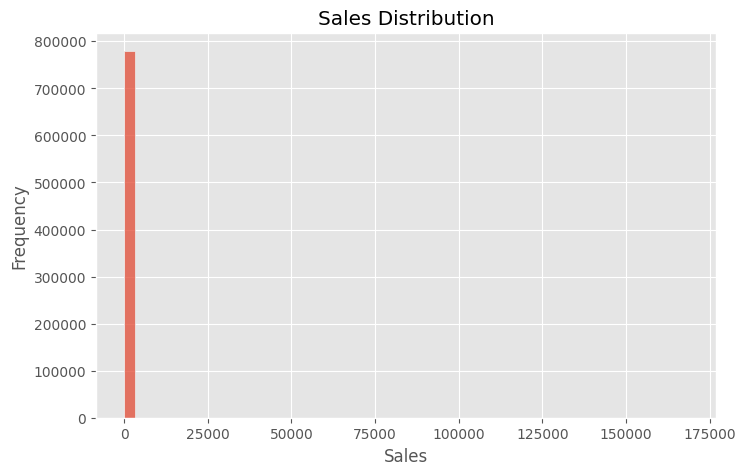

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Sales"], bins=50)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

### Business insight

#### top 10counteies by sales

In [7]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)
country_sales

Country
United Kingdom    1.438923e+07
EIRE              6.165705e+05
Netherlands       5.540381e+05
Germany           4.250197e+05
France            3.487690e+05
Australia         1.692835e+05
Spain             1.083325e+05
Switzerland       1.000619e+05
Sweden            9.151582e+04
Denmark           6.858069e+04
Name: Sales, dtype: float64

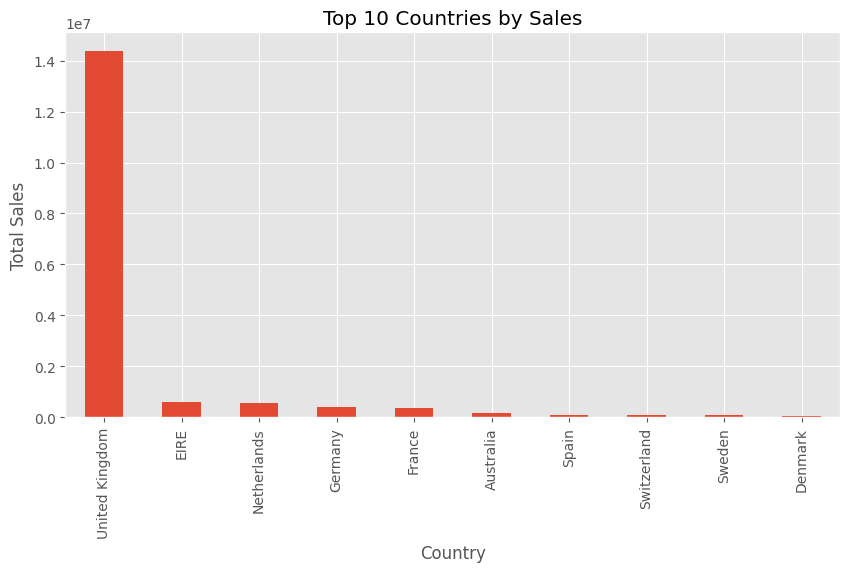

In [8]:
plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")

plt.show()

### monthly sales trends

In [9]:
monthly_sales = df.groupby("Month")["Sales"].sum()
monthly_sales

Month
1     1123903.982
2      950643.876
3     1291060.231
4     1060356.333
5     1275188.530
6     1296417.180
7     1188699.071
8     1246275.640
9     1779704.153
10    2068754.460
11    2322665.632
12    1771135.180
Name: Sales, dtype: float64

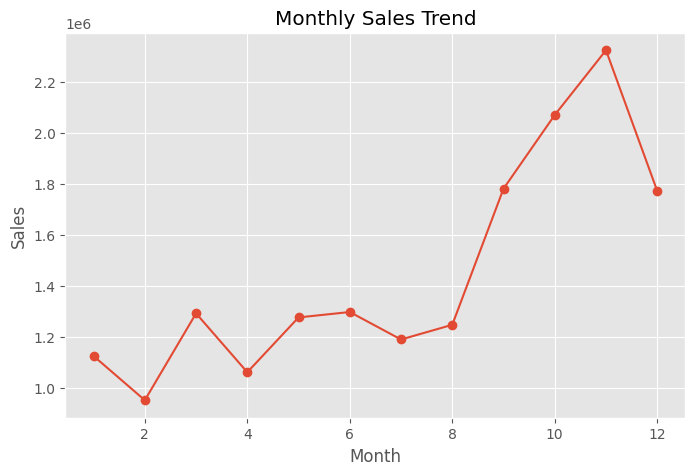

In [10]:
plt.figure(figsize=(8,5))
monthly_sales.plot(marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

### Top selling products

In [11]:
top_products = df.groupby("Description")["Quantity"].sum().sort_values(ascending=False).head(10)
top_products

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     105185
WHITE HANGING HEART T-LIGHT HOLDER     91757
PAPER CRAFT , LITTLE BIRDIE            80995
ASSORTED COLOUR BIRD ORNAMENT          78234
MEDIUM CERAMIC TOP STORAGE JAR         77916
JUMBO BAG RED RETROSPOT                74224
BROCADE RING PURSE                     70082
PACK OF 60 PINK PAISLEY CAKE CASES     54592
60 TEATIME FAIRY CAKE CASES            52828
PACK OF 72 RETRO SPOT CAKE CASES       45129
Name: Quantity, dtype: int64

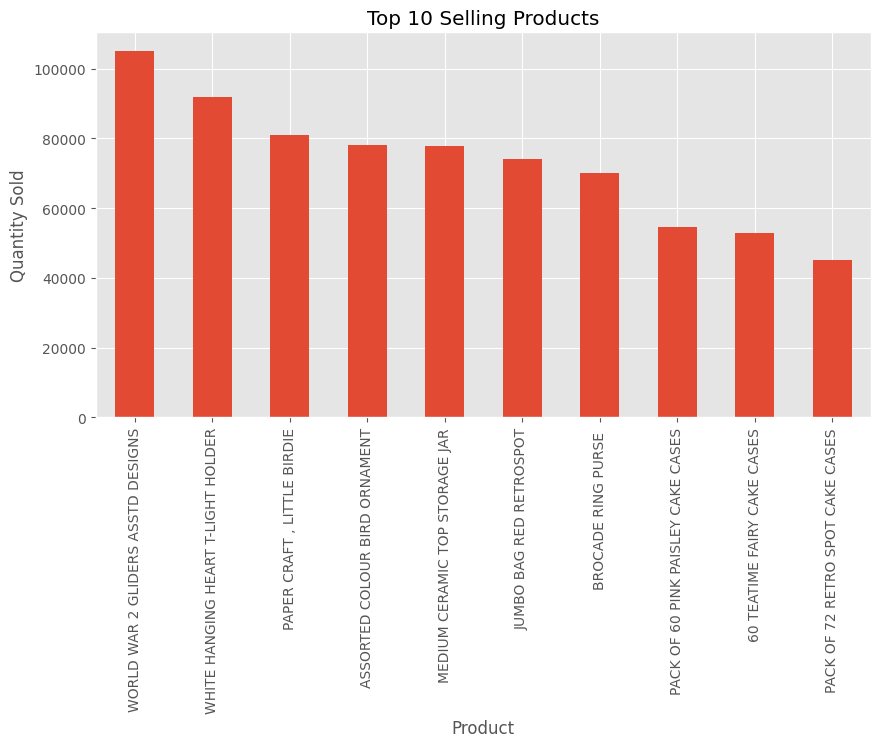

In [12]:
plt.figure(figsize=(10,5))
top_products.plot(kind="bar")
plt.title("Top 10 Selling Products")
plt.xlabel("Product")
plt.ylabel("Quantity Sold")

plt.show()

### Top Customers by revenue

In [13]:
top_customers = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(10)
top_customers

Customer ID
18102.0    580987.04
14646.0    528602.52
14156.0    313437.62
14911.0    291420.81
17450.0    244784.25
13694.0    195640.69
17511.0    172132.87
16446.0    168472.50
16684.0    147142.77
12415.0    144458.37
Name: Sales, dtype: float64

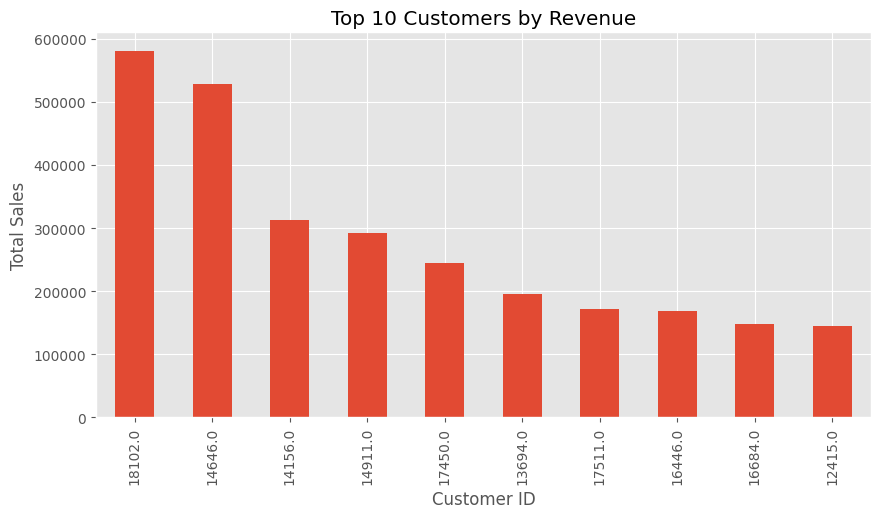

In [14]:
plt.figure(figsize=(10,5))
top_customers.plot(kind="bar")
plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Total Sales")

plt.show()

### Customer Purchase Behavior

In [15]:
customer_orders = df.groupby("Customer ID")["Invoice"].nunique()
customer_orders.describe()

count    5878.000000
mean        6.289384
std        13.009406
min         1.000000
25%         1.000000
50%         3.000000
75%         7.000000
max       398.000000
Name: Invoice, dtype: float64

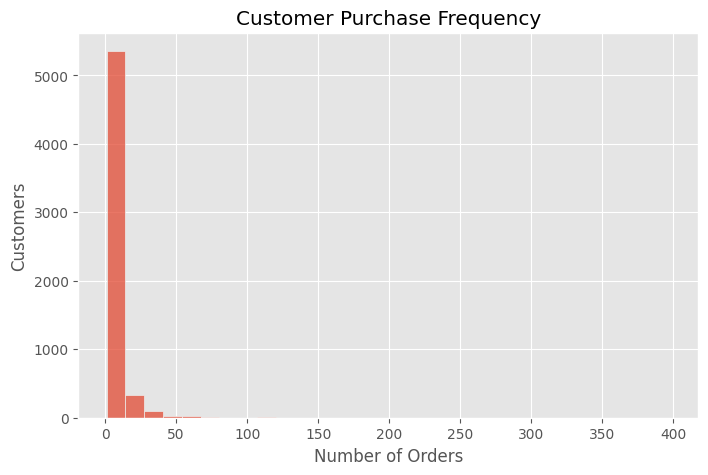

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(customer_orders, bins=30)
plt.title("Customer Purchase Frequency")
plt.xlabel("Number of Orders")
plt.ylabel("Customers")

plt.show()